In [3]:
from sklearn import neighbors, tree, ensemble, svm, model_selection, metrics
import pandas as pd
import warnings
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
def load_data(path):
    dataset = pd.read_csv(path)
    X = dataset.drop(['version', 'name', 'name.1', 'bug'], axis=1)
    y = dataset['bug'].copy()

    correlation_coefficients = X.corrwith(y)

    sns.set(style="whitegrid")
    plt.figure(figsize=(10, 6))
    sns.barplot(data=pd.DataFrame({'Feature': correlation_coefficients.index, 'Pearson Correlation': correlation_coefficients.values}), x='Feature', y='Pearson Correlation', palette="Set3")
    plt.title('Pearson Correlation Coefficients between X Features and y')
    plt.ylabel('Pearson Correlation')
    plt.xticks(rotation=45)
    plt.show()

    y[y > 0] = 1

    return X, y


/var/folders/hy/twfcqn3x3bx9pl76gnl7lt100000gn/T/ipykernel_51076/3375809095.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pd.DataFrame({'Feature': correlation_coefficients.index, 'Pearson Correlation': correlation_coefficients.values}), x='Feature', y='Pearson Correlation', palette="Set3")


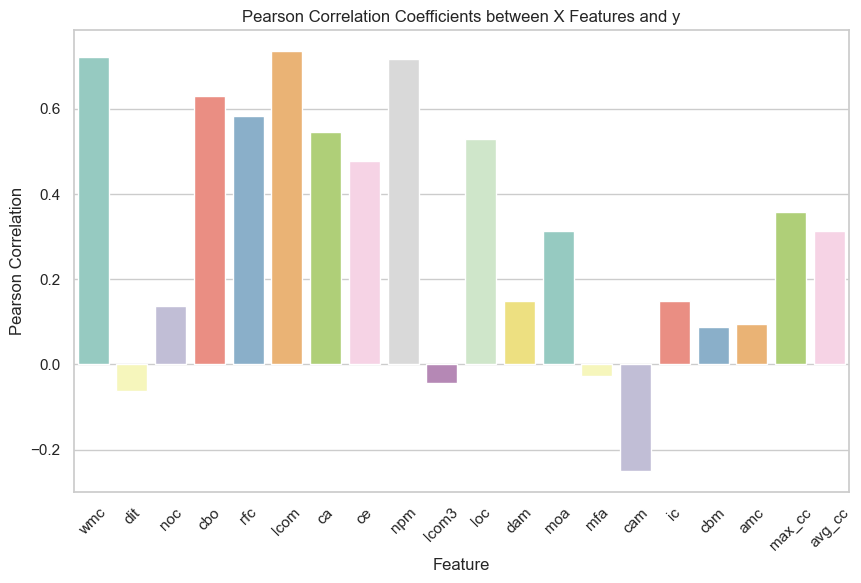

In [5]:
X, y = load_data('resource/oo/log4j/log4j-1.0.csv')

In [6]:
knn_model = neighbors.KNeighborsClassifier(n_neighbors=5)
dt_model = tree.DecisionTreeClassifier()
rf_model = ensemble.RandomForestClassifier()
gbm_model = ensemble.GradientBoostingClassifier()

X_fit, X_blindtest, y_fit, y_blindtest = model_selection.train_test_split(X, y, test_size=0.3)

models = [knn_model, dt_model, rf_model, gbm_model]
for m in models:
    print('\n'+str(m))
    precision_cv_score = model_selection.cross_val_score(m, X_fit, y_fit, cv=5, scoring='precision_macro').mean()
    recall_cv_score = model_selection.cross_val_score(m, X_fit, y_fit, cv=5, scoring='recall_macro').mean()
    print('CV: p:{0:.2f} r:{1:.2f}'.format(precision_cv_score, recall_cv_score))

    m.fit(X_fit, y_fit)

    precision_test_score = metrics.precision_score(m.predict(X_blindtest), y_blindtest, average='macro')
    recall_test_score = metrics.recall_score(m.predict(X_blindtest), y_blindtest, average='macro')

    print('test: p:{0:.2f} r:{1:.2f}'.format(precision_test_score, recall_test_score))


KNeighborsClassifier()
CV: p:0.63 r:0.59
test: p:0.72 r:0.78

DecisionTreeClassifier()
CV: p:0.62 r:0.63
test: p:0.83 r:0.80

RandomForestClassifier()
CV: p:0.66 r:0.64
test: p:0.84 r:0.84

GradientBoostingClassifier()
CV: p:0.61 r:0.60
test: p:0.69 r:0.69


/var/folders/hy/twfcqn3x3bx9pl76gnl7lt100000gn/T/ipykernel_51076/3375809095.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pd.DataFrame({'Feature': correlation_coefficients.index, 'Pearson Correlation': correlation_coefficients.values}), x='Feature', y='Pearson Correlation', palette="Set3")


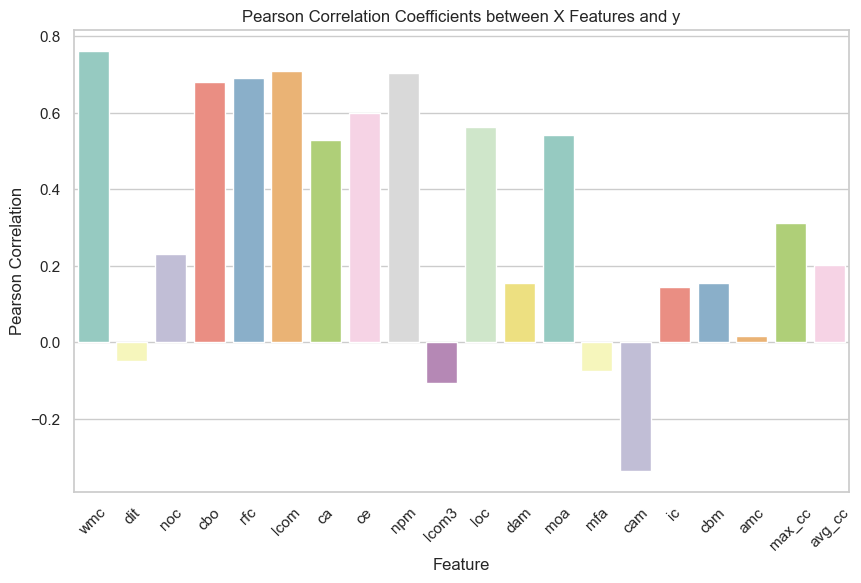


KNeighborsClassifier()
forward test: p:0.67 r:0.79

DecisionTreeClassifier()
forward test: p:0.69 r:0.73

RandomForestClassifier()
forward test: p:0.75 r:0.79

GradientBoostingClassifier()
forward test: p:0.77 r:0.81


In [7]:
X_t, y_t = load_data('resource/oo/log4j/log4j-1.1.csv')
for m in models:
    print('\n'+str(m))
    m.fit(X, y)

    precision_test_score = metrics.precision_score(m.predict(X_t), y_t, average='macro')
    recall_test_score = metrics.recall_score(m.predict(X_t), y_t, average='macro')

    print('forward test: p:{0:.2f} r:{1:.2f}'.format(precision_test_score, recall_test_score))

/var/folders/hy/twfcqn3x3bx9pl76gnl7lt100000gn/T/ipykernel_51076/3375809095.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pd.DataFrame({'Feature': correlation_coefficients.index, 'Pearson Correlation': correlation_coefficients.values}), x='Feature', y='Pearson Correlation', palette="Set3")


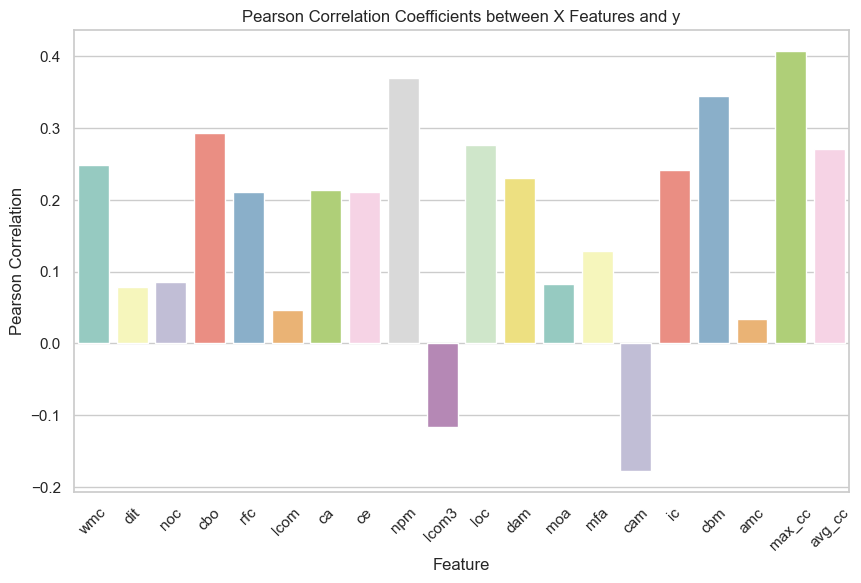


KNeighborsClassifier()
forward test 2: p:0.61 r:0.55

DecisionTreeClassifier()
forward test 2: p:0.63 r:0.54

RandomForestClassifier()
forward test 2: p:0.65 r:0.55

GradientBoostingClassifier()
forward test 2: p:0.65 r:0.55


In [8]:
X_t2, y_t2 = load_data('resource/oo/log4j/log4j-1.2.csv')
for m in models:
    print('\n'+str(m))
    m.fit(X, y)

    precision_test_score = metrics.precision_score(m.predict(X_t2), y_t2, average='macro')
    recall_test_score = metrics.recall_score(m.predict(X_t2), y_t2, average='macro')

    print('forward test 2: p:{0:.2f} r:{1:.2f}'.format(precision_test_score, recall_test_score))

In [9]:
for m in models:
    print('\n'+str(m))
    m.fit(X_t, y_t)

    precision_test_score = metrics.precision_score(m.predict(X_t2), y_t2, average='macro')
    recall_test_score = metrics.recall_score(m.predict(X_t2), y_t2, average='macro')

    print('forward test 2: p:{0:.2f} r:{1:.2f}'.format(precision_test_score, recall_test_score))


KNeighborsClassifier()
forward test 2: p:0.57 r:0.53

DecisionTreeClassifier()
forward test 2: p:0.39 r:0.47

RandomForestClassifier()
forward test 2: p:0.55 r:0.52

GradientBoostingClassifier()
forward test 2: p:0.56 r:0.52
